In [1]:
import os
import random
import cv2
import numpy as np
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =========================
# 1. Dataset paths
# =========================
alz_dirs = {
    "Alzheimer_MildDemented": r'/kaggle/input/brain-tumor-and-alzheimers-disease-dataset/archive (14)/AugmentedAlzheimerDataset/MildDemented',
    "Alzheimer_ModerateDemented": r'/kaggle/input/brain-tumor-and-alzheimers-disease-dataset/archive (14)/AugmentedAlzheimerDataset/ModerateDemented',
    "Alzheimer_VeryMildDemented": r'/kaggle/input/brain-tumor-and-alzheimers-disease-dataset/archive (14)/AugmentedAlzheimerDataset/VeryMildDemented',
    "Alzheimer_NonDemented": r'/kaggle/input/brain-tumor-and-alzheimers-disease-dataset/archive (14)/AugmentedAlzheimerDataset/NonDemented'
}

tumor_dirs = {
    "BrainTumor_Normal": r'/kaggle/input/brain-tumor-and-alzheimers-disease-dataset/archive (13)/Data/Normal',
    "BrainTumor_Glioma": r'/kaggle/input/brain-tumor-and-alzheimers-disease-dataset/archive (13)/Data/Tumor/glioma_tumor',
    "BrainTumor_Meningioma": r'/kaggle/input/brain-tumor-and-alzheimers-disease-dataset/archive (13)/Data/Tumor/meningioma_tumor',
    "BrainTumor_Pituitary": r'/kaggle/input/brain-tumor-and-alzheimers-disease-dataset/archive (13)/Data/Tumor/pituitary_tumor'
}

combined_dirs = {**alz_dirs, **tumor_dirs}

output_root = '/kaggle/working/balanced_combined_dataset'

# =========================
# 2. Image augmentation
# =========================
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# =========================
# 3. Function to balance and augment
# =========================
def augment_folder(source_dir, target_count, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    files = os.listdir(source_dir)
    
    # Copy original images first
    for f in files:
        shutil.copy(os.path.join(source_dir, f), os.path.join(output_dir, f))
    
    while len(os.listdir(output_dir)) < target_count:
        img_path = os.path.join(source_dir, random.choice(files))
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = np.expand_dims(img, 0)
        
        for batch in datagen.flow(img, batch_size=1, save_to_dir=output_dir,
                                  save_prefix='aug', save_format='jpg'):
            if len(os.listdir(output_dir)) >= target_count:
                break

# =========================
# 4. Balance all classes together
# =========================
# Find the maximum number of images among all classes
max_count = max(len(os.listdir(d)) for d in combined_dirs.values())

for class_name, class_dir in combined_dirs.items():
    output_dir = os.path.join(output_root, class_name)
    print(f"Balancing class {class_name}...")
    augment_folder(class_dir, max_count, output_dir)

print(f"\nCombined balanced dataset saved at {output_root}")


2025-09-11 16:56:37.313010: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757609797.515747      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757609797.578707      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Balancing class Alzheimer_MildDemented...
Balancing class Alzheimer_ModerateDemented...
Balancing class Alzheimer_VeryMildDemented...
Balancing class Alzheimer_NonDemented...
Balancing class BrainTumor_Normal...
Balancing class BrainTumor_Glioma...
Balancing class BrainTumor_Meningioma...
Balancing class BrainTumor_Pituitary...

Combined balanced dataset saved at /kaggle/working/balanced_combined_dataset


In [2]:
import os

root = '/kaggle/working/balanced_combined_dataset'
for cls in os.listdir(root):
    print(cls, ":", len(os.listdir(os.path.join(root, cls))))


BrainTumor_Meningioma : 9600
Alzheimer_VeryMildDemented : 9600
BrainTumor_Glioma : 9600
Alzheimer_ModerateDemented : 9600
BrainTumor_Pituitary : 9600
Alzheimer_NonDemented : 9600
BrainTumor_Normal : 9600
Alzheimer_MildDemented : 9600


                                           filepaths                 labels
0  /kaggle/working/balanced_combined_dataset/Brai...  BrainTumor_Meningioma
1  /kaggle/working/balanced_combined_dataset/Brai...  BrainTumor_Meningioma
2  /kaggle/working/balanced_combined_dataset/Brai...  BrainTumor_Meningioma
3  /kaggle/working/balanced_combined_dataset/Brai...  BrainTumor_Meningioma
4  /kaggle/working/balanced_combined_dataset/Brai...  BrainTumor_Meningioma
labels
BrainTumor_Meningioma         9600
Alzheimer_VeryMildDemented    9600
BrainTumor_Glioma             9600
Alzheimer_ModerateDemented    9600
BrainTumor_Pituitary          9600
Alzheimer_NonDemented         9600
BrainTumor_Normal             9600
Alzheimer_MildDemented        9600
Name: count, dtype: int64
Train: (53758, 2)
Validation: (11522, 2)
Test: (11520, 2)
Found 53758 validated image filenames belonging to 8 classes.
Found 11522 validated image filenames belonging to 8 classes.
Found 11520 validated image filenames belonging t

I0000 00:00:1757610393.761173      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb7 (Functional)     │ (None, 2560)           │    64,097,687 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       327,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/10


I0000 00:00:1757610487.194392      58 service.cc:148] XLA service 0x7e7f48003b40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757610487.195161      58 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1757610495.891348      58 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1757610510.407884      58 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757610510.672664      58 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757610511.195510      58 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757610511.4608

 381/1680 ━━━━━━━━━━━━━━━━━━━━ 6:51 317ms/step - accuracy: 0.5058 - loss: 1.5866

E0000 00:00:1757610684.640533      58 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757610684.908685      58 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757610685.435436      58 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757610685.702799      58 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1757610686.524177      58 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

1680/1680 ━━━━━━━━━━━━━━━━━━━━ 824s 406ms/step - accuracy: 0.6247 - loss: 1.0122 - val_accuracy: 0.8239 - val_loss: 0.3996 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.00095.
Epoch 2/10
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 600s 357ms/step - accuracy: 0.8167 - loss: 0.4391 - val_accuracy: 0.9002 - val_loss: 0.2471 - learning_rate: 9.5000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0009025.
Epoch 3/10
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 600s 357ms/step - accuracy: 0.8923 - loss: 0.2745 - val_accuracy: 0.9398 - val_loss: 0.1479 - learning_rate: 9.0250e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.000857375.
Epoch 4/10
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 600s 357ms/step - accuracy: 0.9355 - loss: 0.1736 - val_accuracy: 0.9622 - val_loss: 0.1073 - learning_rate: 8.5737e-04

Epoch 5: LearningRateScheduler setting learning rate to 0.0008145062499999999.
Epoch 5/10
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 601s 358ms/step - accuracy: 0.9551 - loss

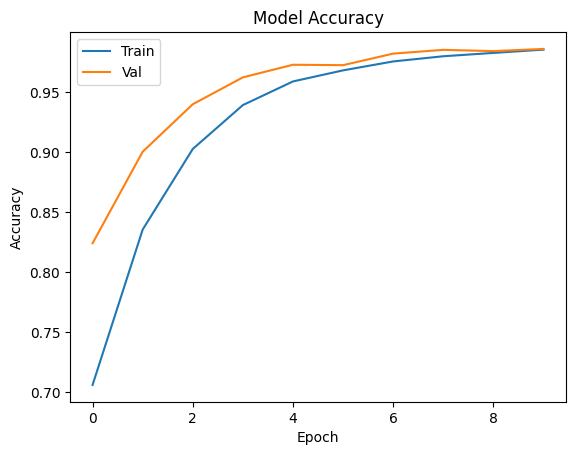

360/360 ━━━━━━━━━━━━━━━━━━━━ 83s 182ms/step
                            precision    recall  f1-score   support

    Alzheimer_MildDemented       0.99      1.00      0.99      1440
Alzheimer_ModerateDemented       1.00      1.00      1.00      1440
     Alzheimer_NonDemented       0.99      0.97      0.98      1440
Alzheimer_VeryMildDemented       0.97      0.97      0.97      1440
         BrainTumor_Glioma       0.99      0.98      0.99      1440
     BrainTumor_Meningioma       0.98      0.99      0.99      1440
         BrainTumor_Normal       0.99      1.00      0.99      1440
      BrainTumor_Pituitary       1.00      1.00      1.00      1440

                  accuracy                           0.99     11520
                 macro avg       0.99      0.99      0.99     11520
              weighted avg       0.99      0.99      0.99     11520



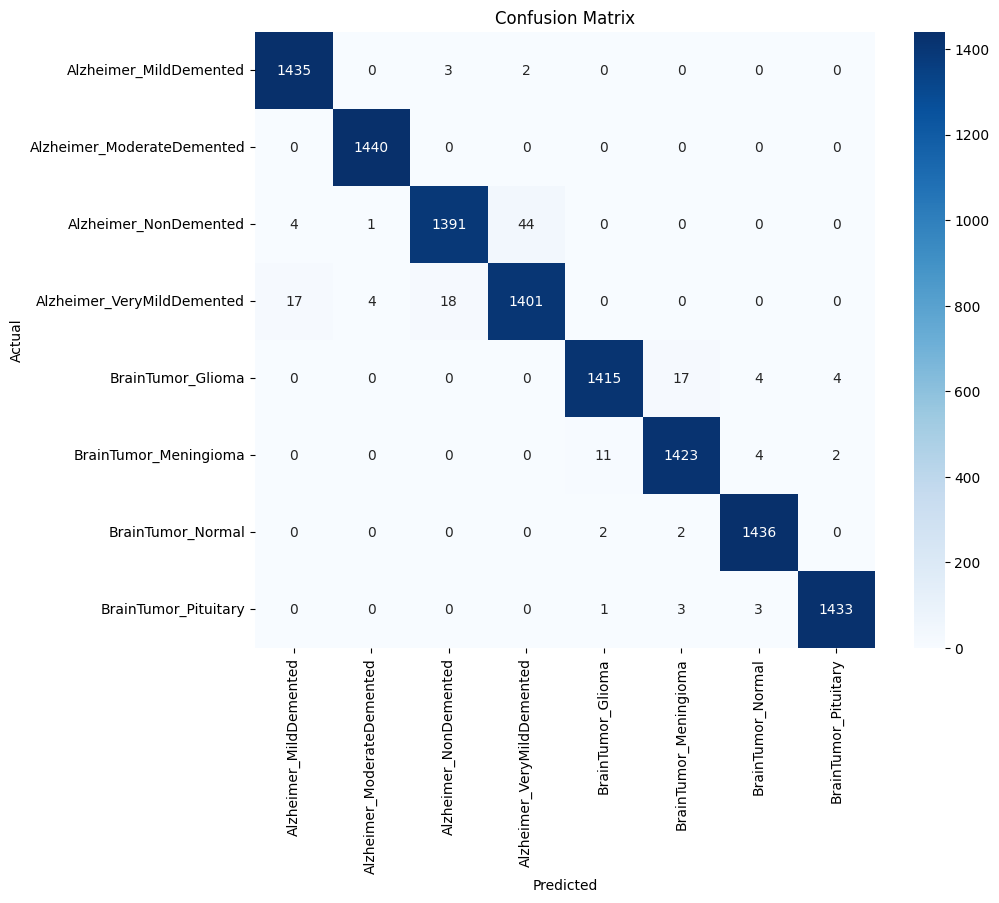

In [3]:
# =========================
# 1. Imports
# =========================
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.applications import EfficientNetB7
from sklearn.model_selection import train_test_split

# =========================
# 2. Dataset paths
# =========================
combined_root = '/kaggle/working/balanced_combined_dataset'  # Update this path

classes = os.listdir(combined_root)  # 8 classes

filepaths = []
labels = []

for cls in classes:
    cls_path = os.path.join(combined_root, cls)
    files = os.listdir(cls_path)
    for f in files:
        filepaths.append(os.path.join(cls_path, f))
        labels.append(cls)

df = pd.DataFrame({"filepaths": filepaths, "labels": labels})
print(df.head())
print(df["labels"].value_counts())

# =========================
# 3. Stratified train/val/test split
# =========================
# Split 70% train+val, 15% test
train_val, test_set = train_test_split(
    df, test_size=0.15, stratify=df['labels'], random_state=42
)

# Split train_val into 85% train, 15% val (0.85*0.85 ≈ 72.25% train, 0.15*0.85 ≈ 12.75% val)
train_set, val_set = train_test_split(
    train_val, test_size=0.1765, stratify=train_val['labels'], random_state=42
)

print("Train:", train_set.shape)
print("Validation:", val_set.shape)
print("Test:", test_set.shape)

# =========================
# 4. Image Data Generators
# =========================
image_gen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

train = image_gen.flow_from_dataframe(
    dataframe=train_set,
    x_col="filepaths",
    y_col="labels",
    target_size=(244,244),
    color_mode='rgb',
    class_mode="categorical",
    batch_size=32,
    shuffle=True
)

val = image_gen.flow_from_dataframe(
    dataframe=val_set,
    x_col="filepaths",
    y_col="labels",
    target_size=(244,244),
    color_mode='rgb',
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)

test = image_gen.flow_from_dataframe(
    dataframe=test_set,
    x_col="filepaths",
    y_col="labels",
    target_size=(244,244),
    color_mode='rgb',
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)

# =========================
# 5. Build EfficientNetB7 model
# =========================
img_shape = (244,244,3)
base_model = EfficientNetB7(include_top=False, weights="imagenet", input_shape=img_shape, pooling='max')
base_model.trainable = True

# Fine-tune from block6a_expand_conv onwards
set_trainable = False
for layer in base_model.layers:
    if layer.name == 'block6a_expand_conv':
        set_trainable = True
    layer.trainable = set_trainable

EfficientNetB7_model = Sequential([
    tf.keras.layers.InputLayer(input_shape=img_shape),
    base_model,
    Flatten(),
    Dropout(rate=0.3),
    Dense(128, activation='relu'),
    Dropout(rate=0.25),
    Dense(len(classes), activation='softmax')  # 8 classes
])

EfficientNetB7_model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EfficientNetB7_model.summary()

# =========================
# 6. Train the model
# =========================
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler

annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = EfficientNetB7_model.fit(
    train,
    validation_data=val,
    epochs=10,
    callbacks=[annealer, early_stop]
)

# =========================
# 7. Plot accuracy
# =========================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# =========================
# 8. Save the model
# =========================
EfficientNetB7_model.save("EfficientNetB7_combined_dataset.keras")

# =========================
# 9. Evaluate on Test Set
# =========================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

test.reset()
preds = EfficientNetB7_model.predict(test, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test.classes
class_names = list(test.class_indices.keys())

# Classification report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


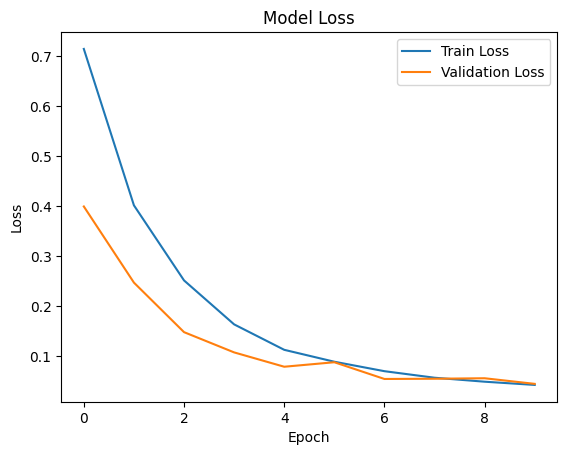

In [4]:
# =========================
# 7.1 Plot loss
# =========================
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()


In [5]:
import shutil
from IPython.display import FileLink

# 1. Path to your saved model
model_path = '/kaggle/working/EfficientNetB7_combined_dataset.keras'

# 2. Zip the model file
shutil.make_archive('/kaggle/working/EfficientNetB7_combined_dataset', 'zip', '/kaggle/working', 'EfficientNetB7_combined_dataset.keras')

# 3. Create a clickable download link
FileLink('/kaggle/working/EfficientNetB7_combined_dataset.zip')


/kaggle/working/EfficientNetB7_combined_dataset.zip

In [6]:
from graphviz import Digraph

# Initialize directed graph
dot = Digraph(format='png')
dot.attr(rankdir='TB', size='8,12', bgcolor='white', fontname="Helvetica")

# Define each layer with visual styling
creative_layers = [
    ("Input", "🎯 Input Layer\n(244×244×3)", "#FFD700"),        # Gold
    ("EffNetB7", "🧠 EfficientNetB7\n(pretrained, 813 layers)", "#FF6F61"),  # Coral
    ("Flatten", "📏 Flatten\n(1D conversion)", "#98FB98"),       # Pale green
    ("Dropout1", "🚿 Dropout\n(rate=0.3)", "#87CEFA"),           # Sky blue
    ("Dense1", "💡 Dense Layer\n(128 neurons, ReLU)", "#DA70D6"), # Orchid
    ("Dropout2", "🚿 Dropout\n(rate=0.25)", "#87CEFA"),          # Sky blue
    ("Output", "🚪 Output Layer\n(8 classes, Softmax)", "#D8BFD8")  # Thistle
]

# Add each layer as a styled node
for name, label, color in creative_layers:
    dot.node(name, label=label, shape='box', style='filled,rounded,bold',
             color=color, fontcolor="black", fontsize="14")

# Connect layers with stylized arrows
for i in range(len(creative_layers) - 1):
    dot.edge(creative_layers[i][0], creative_layers[i+1][0],
             arrowhead='diamond', arrowsize='1.5', color='black', penwidth='2')

# Save the diagram to a file (no auto-open)
dot.render('Creative_Custom_EfficientNetB7_Model')


'Creative_Custom_EfficientNetB7_Model.png'

In [7]:
from kaggle_secrets import UserSecretsClient
from IPython.display import FileLink

# Create a clickable download link
FileLink("Creative_Custom_EfficientNetB7_Model.png")


/kaggle/working/Creative_Custom_EfficientNetB7_Model.png